# PPC3: Condução transiente 1D com diferenças finitas implícitas


# Aluno: Felipe Tavares Loureiro  
# Professor: Rafael Gabler Gontijo
# Disciplina: ENM0227 - Cálculo Numérico Aplicado  
# Semestre: 2026.1



# Questão 1 - Caso sem geração interna e validação com solução exata

Nesta primeira parte, o objetivo é resolver numericamente a condução transiente 1D sem geração interna, usando diferenças finitas no espaço, esquema implícito no tempo e algoritmo de Thomas para resolver o sistema tridiagonal.

O modelo físico sem geração interna é:

$$
\frac{\partial T}{\partial t}=\alpha\frac{\partial^2 T}{\partial x^2}
$$

com:

$$
\alpha = \frac{k}{\rho c_p}
$$

O domínio numérico é $0 \leq x \leq L$. Em $x=0$, usa-se simetria adiabática. Em $x=L$, usa-se convecção com o fluido externo a temperatura $T_\infty$.

A temperatura inicial é uniforme:

$$
T(x,0)=T_i
$$

Define-se:

$$
r=\frac{\alpha\Delta t}{\Delta x^2}
$$

Para os nós internos, o esquema implícito gera:

$$
-rT_{i-1}^{p+1}+(1+2r)T_i^{p+1}-rT_{i+1}^{p+1}=T_i^p
$$

No nó de simetria:

$$
(1+2r)T_0^{p+1}-2rT_1^{p+1}=T_0^p
$$

No nó convectivo:

$$
-2rT_{N-2}^{p+1}+\left(1+2r+2rBi_{\Delta x}\right)T_{N-1}^{p+1}=T_{N-1}^{p}+2rBi_{\Delta x}T_\infty
$$

onde:

$$
Bi_{\Delta x}=\frac{h\Delta x}{k}
$$

Para a validação com a solução exata, usa-se o número de Biot global:

$$
Bi=\frac{hL}{k}
$$

A solução exata adimensional fornecida no enunciado é:

$$
\theta(x^*,Fo)=\sum_{n=1}^{\infty}\left[\frac{4\sin(\lambda_n)}{2\lambda_n+\sin(2\lambda_n)}\right]\cos(\lambda_nx^*)e^{-\lambda_n^2Fo}
$$

com:

$$
\theta=\frac{T-T_\infty}{T_i-T_\infty},\qquad x^*=\frac{x}{L},\qquad Fo=\frac{\alpha t}{L^2}
$$

As raízes $\lambda_n$ satisfazem:

$$
\lambda_n\tan(\lambda_n)=Bi
$$


In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


def thomas(a, b, c, d):
    """
    Resolve um sistema tridiagonal Ax = d pelo algoritmo de Thomas.

    a: diagonal inferior, com a[0] = 0
    b: diagonal principal
    c: diagonal superior, com c[-1] = 0
    d: vetor do lado direito
    """

    n = len(d)

    ac = a.astype(float).copy()
    bc = b.astype(float).copy()
    cc = c.astype(float).copy()
    dc = d.astype(float).copy()

    for i in range(1, n):
        fator = ac[i] / bc[i - 1]
        bc[i] = bc[i] - fator * cc[i - 1]
        dc[i] = dc[i] - fator * dc[i - 1]

    x = np.zeros(n)

    x[-1] = dc[-1] / bc[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i + 1]) / bc[i]

    return x


def montar_sistema_implicito(N, r, Bi_dx):
    """
    Monta as três diagonais do sistema implícito.

    N: número de nós
    r: alpha*dt/dx**2
    Bi_dx: h*dx/k, usado na condição convectiva discretizada
    """

    a = np.zeros(N)
    b = np.zeros(N)
    c = np.zeros(N)

    # Nó 0: simetria adiabática.
    b[0] = 1 + 2*r
    c[0] = -2*r

    # Nós internos.
    for i in range(1, N - 1):
        a[i] = -r
        b[i] = 1 + 2*r
        c[i] = -r

    # Último nó: convecção.
    a[-1] = -2*r
    b[-1] = 1 + 2*r + 2*r*Bi_dx
    c[-1] = 0.0

    return a, b, c


def resolver_transiente_1d(
    L=0.05,
    N=51,
    k=16.0,
    rho=8000.0,
    cp=500.0,
    h=100.0,
    T_i=600.0,
    T_inf=300.0,
    dt=0.5,
    t_final=1000.0,
    qdot=0.0,
):
    """
    Resolve o problema transiente 1D com esquema implícito.

    A mesma função serve para:
    - qdot = 0: caso sem geração interna;
    - qdot != 0: caso com geração interna.

    qdot tem unidade W/m^3.
    """

    alpha = k / (rho * cp)

    x = np.linspace(0.0, L, N)
    dx = x[1] - x[0]

    tempos = np.arange(0.0, t_final + dt, dt)

    r = alpha * dt / dx**2

    Bi_L = h * L / k
    Bi_dx = h * dx / k

    a, b, c = montar_sistema_implicito(N, r, Bi_dx)

    T = np.ones(N) * T_i

    historico = np.zeros((len(tempos), N))
    historico[0, :] = T

    # Termo fonte por passo de tempo.
    fonte = qdot * dt / (rho * cp)

    for n in range(1, len(tempos)):
        rhs = T.copy() + fonte

        # Termo convectivo no último nó.
        rhs[-1] = T[-1] + 2*r*Bi_dx*T_inf + fonte

        T = thomas(a, b, c, rhs)

        historico[n, :] = T

    parametros = {
        "L": L,
        "N": N,
        "k": k,
        "rho": rho,
        "cp": cp,
        "h": h,
        "T_i": T_i,
        "T_inf": T_inf,
        "dt": dt,
        "t_final": t_final,
        "qdot": qdot,
        "alpha": alpha,
        "dx": dx,
        "r": r,
        "Bi_L": Bi_L,
        "Bi_dx": Bi_dx,
        "fonte_por_passo": fonte,
    }

    return x, tempos, historico, parametros


def bissecao(f, a, b, tol=1e-12, max_iter=200):
    """
    Método da bisseção para encontrar uma raiz de f no intervalo [a, b].
    """

    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        raise ValueError("O intervalo não contém troca de sinal.")

    for _ in range(max_iter):
        m =(a+ b)/2
        fm = f(m)

        if abs(fm) < tol or abs(b - a) < tol:
            return m

        if fa*fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return (a + b)/2


def calcular_lambdas(Bi_L, n_termos=80):
    """
    Calcula as raízes positivas da equação lambda*tan(lambda) = Bi_L.
    """

    raizes = []
    eps = 1e-10

    def f(lam):
        return lam * np.tan(lam) - Bi_L

    for n in range(1, n_termos + 1):
        a = (n - 1) * np.pi + eps
        b = (n - 0.5) * np.pi - eps
        raizes.append(bissecao(f, a, b))

    return np.array(raizes)


def theta_exata(x_estrela, Fo, Bi_L, n_termos=80):
    """
    Solução exata adimensional fornecida no enunciado.
    """

    lambdas = calcular_lambdas(Bi_L, n_termos=n_termos)

    theta = np.zeros_like(x_estrela, dtype=float)

    for lam in lambdas:
        coef = 4*np.sin(lam) / (2*lam + np.sin(2*lam))
        theta = theta + coef*np.cos(lam*x_estrela)*np.exp(-lam**2 * Fo)

    return theta


def temperatura_exata(x, t, parametros, n_termos=80):
    """
    Converte a solução adimensional exata para temperatura dimensional.
    """

    L = parametros["L"]
    alpha = parametros["alpha"]
    Bi_L = parametros["Bi_L"]
    T_i = parametros["T_i"]
    T_inf = parametros["T_inf"]

    x_estrela = x / L
    Fo = alpha * t / L**2

    theta = theta_exata(x_estrela, Fo, Bi_L, n_termos=n_termos)

    T = T_inf + theta * (T_i - T_inf)

    return T

Parâmetros calculados:
alpha: 4.000000e-06
dx: 1.000000e-03
r: 2.000000e+00
Bi_L: 3.125000e-01
Bi_dx: 6.250000e-03

Tempo de validação: 1000.00 s
Erro relativo L2: 2.144961e-05
Erro máximo absoluto: 1.118503e-02 K


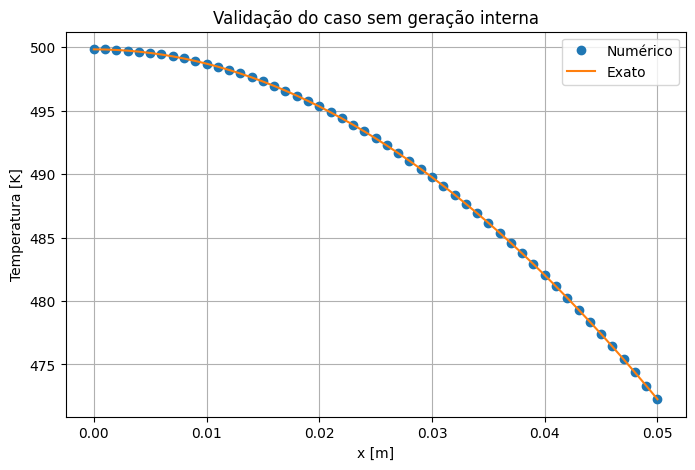

In [12]:
# Parâmetros de base para a validação.
# Ainda não são os valores realistas finais do reator.
# O objetivo dessa parte é testar se o método numérico bate com a solução exata.

parametros_base = {
    "L": 0.05,
    "N": 51,
    "k": 16.0,
    "rho": 8000.0,
    "cp": 500.0,
    "h": 100.0,
    "T_i": 600.0,
    "T_inf": 300.0,
    "dt": 0.5,
    "t_final": 1000.0,
}

x, tempos, hist_sem, params_sem = resolver_transiente_1d(
    **parametros_base,
    qdot=0.0,
)

t_validacao = tempos[-1]
T_num = hist_sem[-1, :]
T_ex = temperatura_exata(x, t_validacao, params_sem, n_termos=80)

erro_L2 = np.linalg.norm(T_num - T_ex) / np.linalg.norm(T_ex)
erro_max = np.max(np.abs(T_num - T_ex))

print("Parâmetros calculados:")
for chave in ["alpha", "dx", "r", "Bi_L", "Bi_dx"]:
    print(f"{chave}: {params_sem[chave]:.6e}")

print("------------------------------------------")
print(f"Tempo de validação: {t_validacao:.2f} s")
print(f"Erro relativo L2: {erro_L2:.6e}")
print(f"Erro máximo absoluto: {erro_max:.6e} K")

print("------------------------------------------")
plt.figure()
plt.plot(x, T_num, "o", label="Numérico")
plt.plot(x, T_ex, "-", label="Exato")
plt.xlabel("x [m]")
plt.ylabel("Temperatura [K]")
plt.title("Validação do caso sem geração interna")
plt.legend()
plt.show()

O erro relativo obtido foi pequeno, indicando que a implementação numérica com diferenças finitas implícitas e algoritmo de Thomas reproduz adequadamente a solução exata para o caso sem geração interna. A mesma malha e o mesmo passo de tempo são então usados como base para os casos posteriores.

# Questão 2 - Acréscimo do termo de geração interna

Nesta parte, a mesma função `resolver_transiente_1d` é usada novamente, agora com $\dot q \neq 0$.

A equação governante passa a ser:

$$
\frac{\partial T}{\partial t}=\alpha\frac{\partial^2T}{\partial x^2}+\frac{\dot q}{\rho c_p}
$$

Como $\dot q$ foi considerado uniforme e independente da temperatura, a matriz tridiagonal não precisa ser alterada. O termo de geração entra somente no lado direito do sistema.

O incremento térmico por passo de tempo é:

$$
S=\frac{\dot q\Delta t}{\rho c_p}
$$

Assim, nos nós internos, a equação fica:

$$
-rT_{i-1}^{p+1}+(1+2r)T_i^{p+1}-rT_{i+1}^{p+1}=T_i^p+S
$$

No nó convectivo:

$$
-2rT_{N-2}^{p+1}+\left(1+2r+2rBi_{\Delta x}\right)T_{N-1}^{p+1}=T_{N-1}^{p}+2rBi_{\Delta x}T_\infty+S
$$

A validação pedida no enunciado é verificar se a solução com geração tende para a solução sem geração quando $\dot q \to 0$:

$$
\lim_{\dot q\to 0}T_{\dot q}(x,t)=T_{\dot q=0}(x,t)
$$


qdot usado: 1.000e+06 W/m^3
fonte por passo de tempo: 1.250000e-01 K por passo


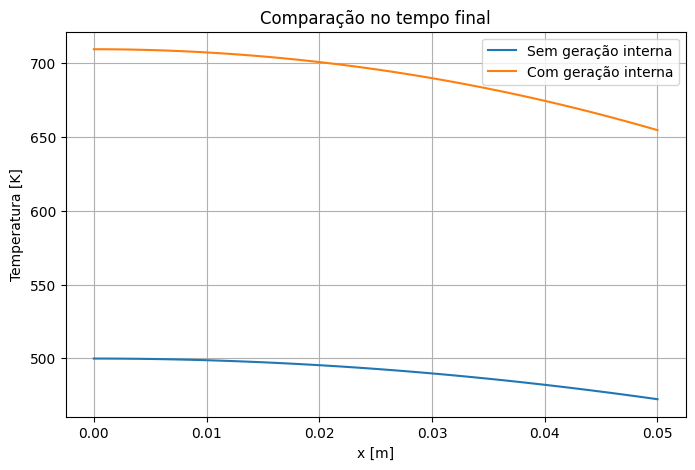

In [13]:
# Caso com geração interna.

qdot_teste = 1.0e6  # W/m^3

x, tempos, hist_gen, params_gen = resolver_transiente_1d(
    **parametros_base,
    qdot=qdot_teste,
)

print(f"qdot usado: {qdot_teste:.3e} W/m^3")
print(f"fonte por passo de tempo: {params_gen['fonte_por_passo']:.6e} K por passo")

plt.figure()
plt.plot(x, hist_sem[-1, :], label="Sem geração interna")
plt.plot(x, hist_gen[-1, :], label="Com geração interna")
plt.xlabel("x [m]")
plt.ylabel("Temperatura [K]")
plt.title("Comparação no tempo final")
plt.legend()
plt.show()

Validação do limite qdot -> 0:

qdot [W/m^3]     erro relativo
   1.000e+06     4.094258e-01
   1.000e+05     4.094258e-02
   1.000e+04     4.094258e-03
   1.000e+03     4.094258e-04
   1.000e+02     4.094258e-05
   1.000e+01     4.094258e-06
   1.000e+00     4.094259e-07
   1.000e-01     4.094252e-08
   1.000e-02     4.094213e-09


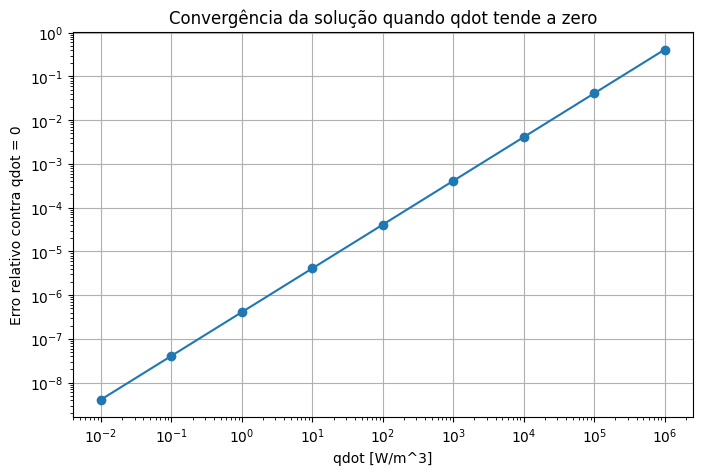

In [14]:
# Validação do limite qdot -> 0.

qdot_valores = np.array([1e6, 1e5, 1e4, 1e3, 1e2, 1e1, 1e0, 1e-1, 1e-2])

T_referencia = hist_sem[-1, :]

erros_limite = []

for qdot in qdot_valores:
    x, tempos, hist_temp, params_temp = resolver_transiente_1d(
        **parametros_base,
        qdot=qdot,
    )

    T_final = hist_temp[-1, :]
    erro = np.linalg.norm(T_final - T_referencia) / np.linalg.norm(T_referencia)

    erros_limite.append(erro)

erros_limite = np.array(erros_limite)

print("Validação do limite qdot -> 0:")
print()
print("qdot [W/m^3]     erro relativo")
for qdot, erro in zip(qdot_valores, erros_limite):
    print(f"{qdot:12.3e}     {erro:12.6e}")

plt.figure()
plt.loglog(qdot_valores, erros_limite, "o-")
plt.xlabel("qdot [W/m^3]")
plt.ylabel("Erro relativo contra qdot = 0")
plt.title("Convergência da solução quando qdot tende a zero")
plt.show()

# Questão 3 - Representações visuais da solução

Nesta parte são testadas diferentes formas de visualização da solução numérica.

Serão gerados:

- perfis de temperatura $T(x)$ em diferentes instantes;
- mapa de cores espaço-tempo para $T(x,t)$;
- evolução temporal da temperatura no centro e na superfície.

Para deixar o efeito da geração interna visível, os gráficos abaixo usam o caso com $\dot q=10^6\,\mathrm{W/m^3}$.


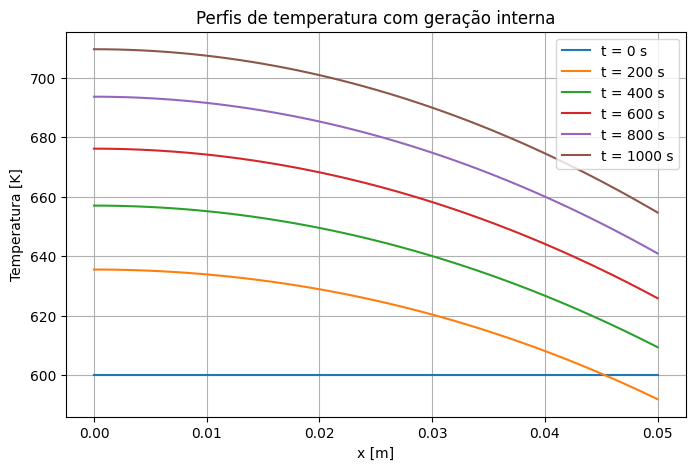

In [15]:
# Perfis de temperatura em diferentes tempos.

indices = [
    0,
    len(tempos)//5,
    2*len(tempos)//5,
    3*len(tempos)//5,
    4*len(tempos)//5,
    len(tempos)-1,
]

plt.figure()

for idx in indices:
    plt.plot(x, hist_gen[idx, :], label=f"t = {tempos[idx]:.0f} s")

plt.xlabel("x [m]")
plt.ylabel("Temperatura [K]")
plt.title("Perfis de temperatura com geração interna")
plt.legend()
plt.show()


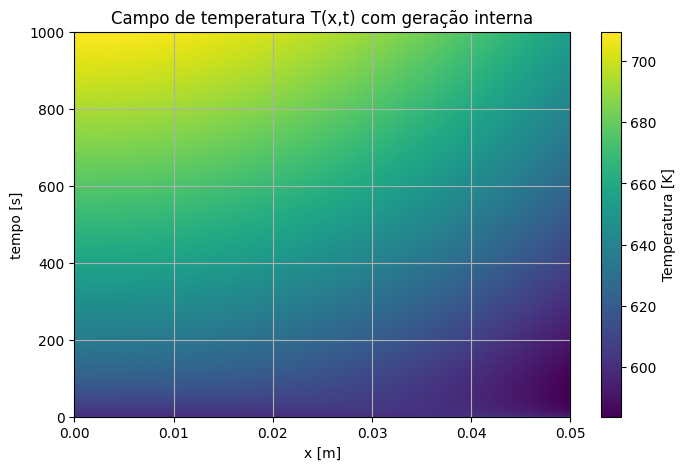

In [16]:
# Mapa de cores espaço-tempo.

plt.figure()
plt.imshow(
    hist_gen,
    aspect="auto",
    origin="lower",
    extent=[x[0], x[-1], tempos[0], tempos[-1]],
)

plt.colorbar(label="Temperatura [K]")
plt.xlabel("x [m]")
plt.ylabel("tempo [s]")
plt.title("Campo de temperatura T(x,t) com geração interna")
plt.show()

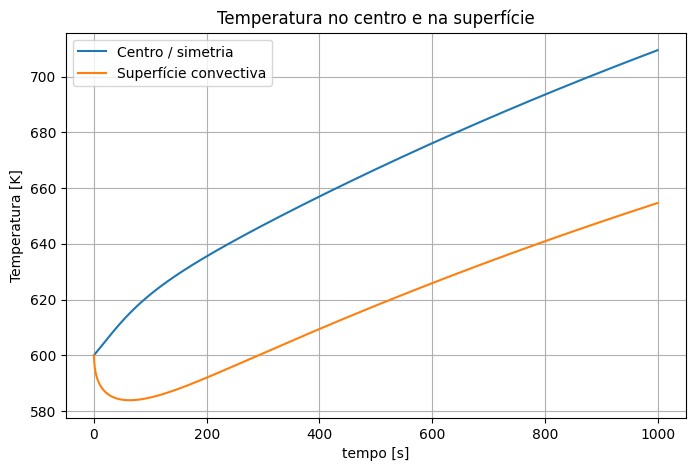

In [17]:
# Evolução da temperatura no centro e na superfície.

T_centro = hist_gen[:, 0]
T_superficie = hist_gen[:, -1]

plt.figure()
plt.plot(tempos, T_centro, label="Centro / simetria")
plt.plot(tempos, T_superficie, label="Superfície convectiva")
plt.xlabel("tempo [s]")
plt.ylabel("Temperatura [K]")
plt.title("Temperatura no centro e na superfície")
plt.legend()
plt.show()

# Questão 4 - Simulação com valores físicos realistas

Para a simulação final, foram adotados valores representativos de uma vareta combustível de reator PWR/AP1000. O material considerado é dióxido de urânio, $UO_2$, e o comprimento característico do modelo 1D foi tomado como o raio do pellet combustível.

Os valores geométricos e operacionais foram retirados da Tabela 1 do artigo de Timoteo, Rosa e Curi sobre a distribuição de temperatura em uma vareta combustível AP1000. Dessa fonte foram usados:

- raio do combustível: $R_f = 4{,}096\times10^{-3}\,\mathrm{m}$;
- geração volumétrica no centro axial da vareta: $\dot q = 3{,}5529\times10^8\,\mathrm{W/m^3}$;
- coeficiente convectivo externo no centro axial: $h = 37023\,\mathrm{W/(m^2K)}$;
- temperatura média do refrigerante no centro axial: $T_\infty = 587\,\mathrm{K}$.

As propriedades termofísicas do $UO_2$ foram retiradas da base da IAEA para temperatura de aproximadamente $1273\,\mathrm{K}$, correspondente a $1000^\circ\mathrm{C}$. Dessa fonte foram usados:

- condutividade térmica: $k = 2{,}79\,\mathrm{W/(mK)}$;
- densidade: $\rho = 10630\,\mathrm{kg/m^3}$;
- calor específico: $c_p = 320\,\mathrm{J/(kgK)}$.

A geração volumétrica adotada foi o valor tabelado para o centro axial da vareta. Observa-se que o texto do artigo também menciona um valor muito próximo, $3{,}5621\times10^8\,\mathrm{W/m^3}$, enquanto a Tabela 1 apresenta $3{,}5529\times10^8\,\mathrm{W/m^3}$. Neste trabalho, foi usado o valor da tabela, por ser a lista consolidada de propriedades e condições de simulação.

Como o modelo implementado neste trabalho é unidimensional plano, o raio do pellet foi usado como comprimento característico da simulação. Portanto, os valores acima são usados para construir um cenário fisicamente plausível, mas o modelo não representa explicitamente geometria cilíndrica, gap, revestimento, propriedades dependentes da temperatura nem perfil axial completo de potência.

## Fontes utilizadas

1. IAEA - *Thermophysical Properties of Materials for Nuclear Engineering*.  
   Usada para propriedades termofísicas do $UO_2$: densidade, calor específico e condutividade térmica.  
   https://www-pub.iaea.org/MTCD/Publications/PDF/IAEA-THPH_web.pdf

2. Timoteo, Rosa e Curi - *Transient Thermal Diffusion and Temperature Distribution of a Cylindrical Fuel Pellet Shifted Radially in Pressurized Water Reactor*.  
   Usada para os valores de geometria AP1000, geração volumétrica, temperatura do refrigerante e coeficiente convectivo.  
   https://www.sistema.abcm.org.br/articleFiles/download/33398

Parâmetros realistas aproximados:
q_linear: 1.873e+04 W/m
qdot estimado: 3.553e+08 W/m^3
alpha: 8.202023e-07
dx: 5.120000e-05
r: 6.257647e+00
Bi_L: 5.435348e+01
Bi_dx: 6.794185e-01
fonte_por_passo: 2.088958e+00


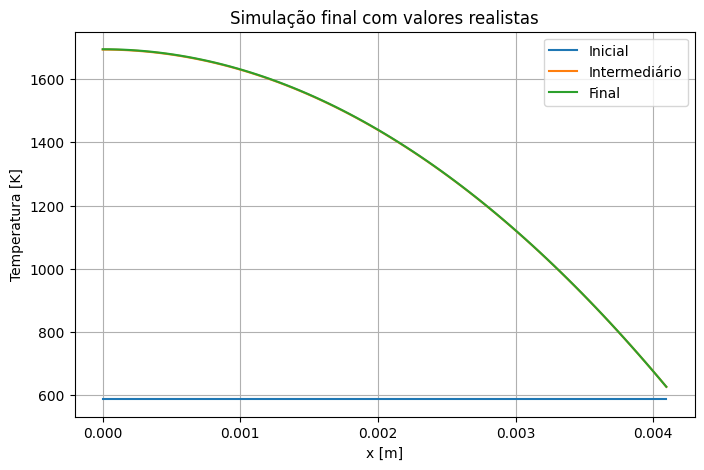

In [18]:
# Parâmetros físicos baseados em dados de vareta combustível AP1000.
# O modelo continua sendo 1D plano, mas os valores são de ordem realista.

R_pellet = 4.096e-3          # m
qdot_realista = 3.5529e8     # W/m^3

parametros_realistas = {
    "L": R_pellet,
    "N": 81,
    "k": 2.79,
    "rho": 10630.0,
    "cp": 320.0,
    "h": 37023.0,
    "T_i": 587.0,
    "T_inf": 587.0,
    "dt": 0.02,
    "t_final": 120.0,
}

x_real, tempos_real, hist_real, params_real = resolver_transiente_1d(
    **parametros_realistas,
    qdot=qdot_realista,
)

q_linear = qdot_realista * np.pi * R_pellet**2

print("Parâmetros realistas usados:")
print(f"q_linear correspondente: {q_linear:.3e} W/m")
print(f"qdot usado: {qdot_realista:.3e} W/m^3")

for chave in ["alpha", "dx", "r", "Bi_L", "Bi_dx", "fonte_por_passo"]:
    print(f"{chave}: {params_real[chave]:.6e}")

plt.figure()
plt.plot(x_real, hist_real[0, :], label="Inicial")
plt.plot(x_real, hist_real[len(tempos_real)//2, :], label="Intermediário")
plt.plot(x_real, hist_real[-1, :], label="Final")
plt.xlabel("x [m]")
plt.ylabel("Temperatura [K]")
plt.title("Simulação final com valores realistas")
plt.legend()
plt.show()

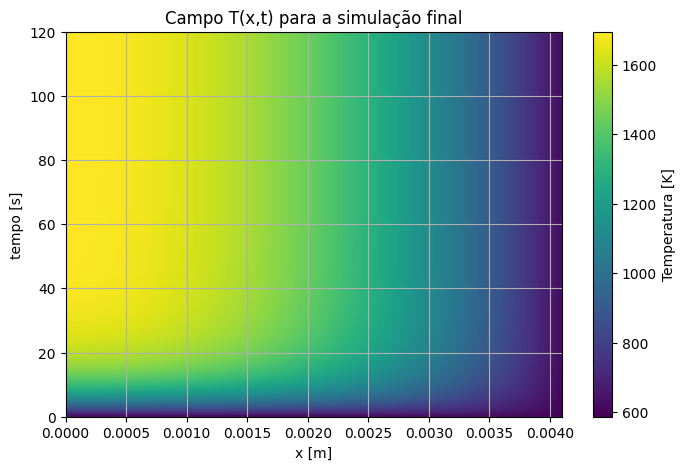

In [19]:
plt.figure()
plt.imshow(
    hist_real,
    aspect="auto",
    origin="lower",
    extent=[x_real[0], x_real[-1], tempos_real[0], tempos_real[-1]],
)

plt.colorbar(label="Temperatura [K]")
plt.xlabel("x [m]")
plt.ylabel("tempo [s]")
plt.title("Campo T(x,t) para a simulação final")
plt.show()

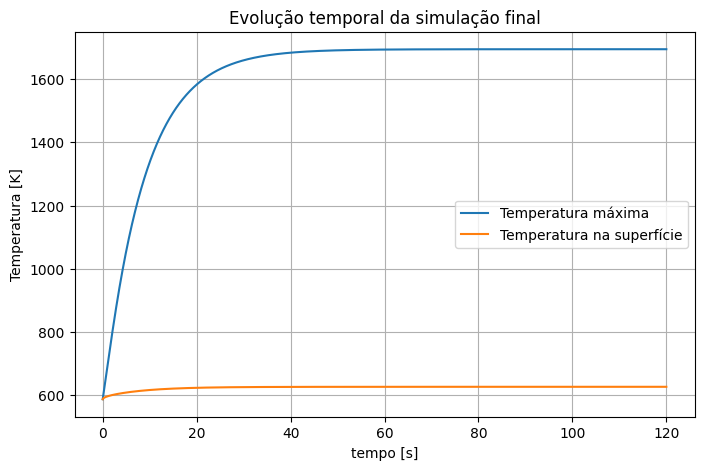

In [20]:
Tmax_real = hist_real.max(axis=1)
Tsup_real = hist_real[:, -1]

plt.figure()
plt.plot(tempos_real, Tmax_real, label="Temperatura máxima")
plt.plot(tempos_real, Tsup_real, label="Temperatura na superfície")
plt.xlabel("tempo [s]")
plt.ylabel("Temperatura [K]")
plt.title("Evolução temporal da simulação final")
plt.legend()
plt.show()

# Conclusões

Os resultados obtidos mostram que o método de diferenças finitas implícito reproduziu bem a solução exata para o caso sem geração interna, com erro relativo pequeno. Isso indica que a discretização, as condições de contorno e o algoritmo de Thomas foram implementados de forma consistente.

Ao adicionar a geração interna, os perfis de temperatura passaram a apresentar aumento progressivo da temperatura no domínio, principalmente próximo à região adiabática. A superfície convectiva permaneceu mais fria em relação ao interior, como esperado, pois é a região pela qual o calor é transferido para o fluido externo.

O teste com valores decrescentes de $\dot q$ confirmou que a solução com geração interna tende para a solução sem geração quando $\dot q \to 0$. Esse resultado funciona como uma verificação adicional da implementação.